In [6]:
import numpy as np 


## Convertendo o mapa de profundidade para .txt
---

In [9]:
import cv2

# Read the image
img = cv2.imread('/home/lelis/Documents/Projetos/hybrid-stereo-method/data/results/hybrid_stereo/media_iluminacao_20250224_1643/depth_map/output.png')

# Convert BGR to RGB (OpenCV uses BGR by default)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Display array shape
print(f"Image shape: {img_gray.shape}")

Image shape: (422, 512)


In [16]:
# Save the grayscale image to a text file
np.savetxt('depht_map.txt', img_gray.reshape(-1,1), fmt='%d', delimiter=',')
print("Image data has been saved to 'depht_map.txt'")

Image data has been saved to 'depht_map.txt'


## Convertendo o mapa de normal para .txt
---

In [13]:
# Read the .npy file
normal_map = np.load('/home/lelis/Documents/Projetos/hybrid-stereo-method/data/results/hybrid_stereo/2025-02-09-stF-melon24-amb0-glo0_20250211_1352/normal_map.npy')
print(f"Loaded array shape: {normal_map.shape}")
print(f"Array data type: {normal_map.dtype}")

Loaded array shape: (422, 512, 3)
Array data type: float64


In [15]:
# Save the 3D array to a text file with float formatting
np.savetxt('normal_map.txt', normal_map.reshape(-1, 3), fmt='%.8f', delimiter=',')
print("Normal map data has been saved to 'normal_map.txt'")

Normal map data has been saved to 'normal_map.txt'


## Testando funções
---

nome:Loaded Image, shape:(422, 512), min:0.000000, max:255.000000, mean:85.365526, rms:10.962600, v_dev:76.810650
Image dimensions: 512x422


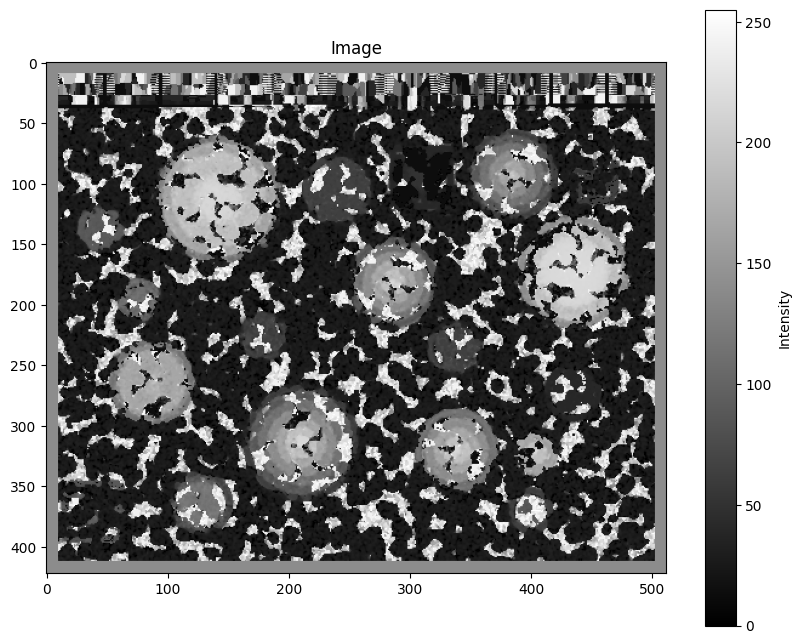

In [ ]:
from common.io import convert_image_array_to_fni, read_image
from common.visualization import display_image
import numpy as np


# Convert a depth map
depth_map = read_image('/home/lelis/Documents/Projetos/hybrid-stereo-method/data/results/hybrid_stereo/media_iluminacao_20250224_1643/depth_map/output.png', info=True)
display_image(image=depth_map,inline=True, cmap='gray', colorbar=True)
depth_map_normalized = (depth_map - depth_map.min()) / (depth_map.max() - depth_map.min()) # Normalize the depth map
convert_image_array_to_fni(depth_map_normalized, 'depth_output.fni')




# Convert a normal map
normal_map = np.load('/home/lelis/Documents/Projetos/hybrid-stereo-method/data/results/hybrid_stereo/2025-02-09-stF-melon24-amb0-glo0_20250303_1156/normal_map.npy')
norms = np.sqrt(np.sum(normal_map**2, axis=2, keepdims=True)) # Compute the norm of each normal vector
normal_map_normalized = normal_map / np.maximum(norms, 1e-10) # Normalize the normal vectors
convert_image_array_to_fni(normal_map, 'normal_output.fni')

In [1]:
from common.visualization import display_image
from common.io import read_fni_to_image_array
import matplotlib.pyplot as plt
import numpy as np

minimum X: -0.9877144694328308, maximum X: 0.9807584881782532
minimum Y: -0.9822477102279663, maximum Y: 0.9876362085342407
minimum Z: 0.11881130933761597, maximum Z: 1.0


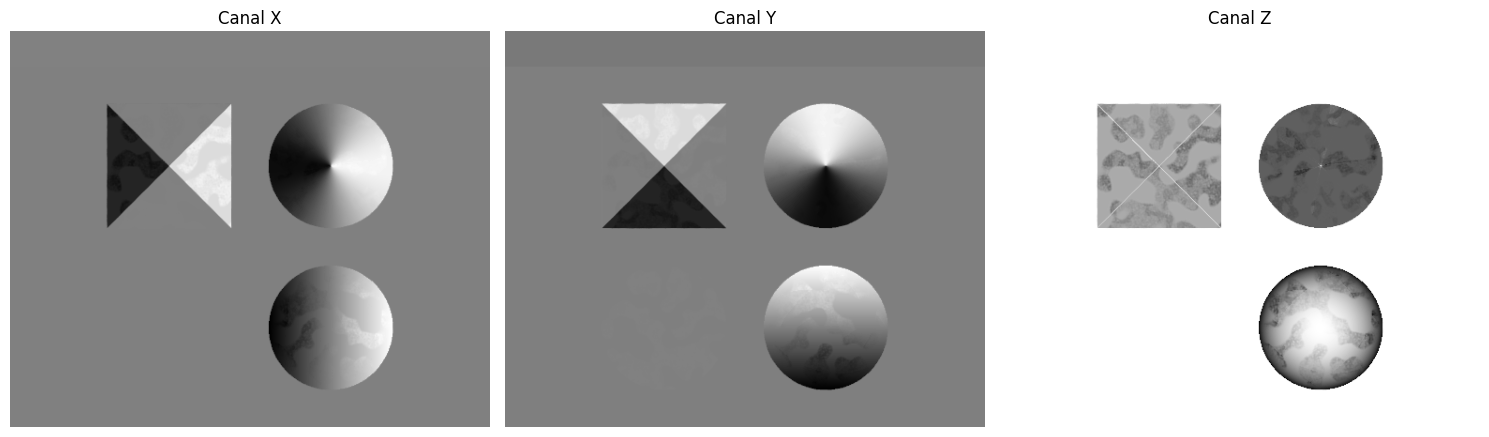

In [11]:
normal_map = read_fni_to_image_array(f'/home/lelis/Documents/Projetos/hybrid-stereo-method/data/results/hybrid_stereo/20250414_1202_images_ps/normal_map_with_residuals.fni')
#display_image(image=image, inline=True, colorbar=True)
# Exibir a imagem
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, channel in enumerate(['X', 'Y', 'Z']):
    print(f'minimum {channel}: {np.min(normal_map[:, :, idx])}, maximum {channel}: {np.max(normal_map[:, :, idx])}')
    axes[idx].imshow(normal_map[:, :, idx], cmap='gray')
    axes[idx].set_title(f"Canal {channel}")
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [12]:
normal_map.shape

(422, 512, 4)

In [4]:
def normal_map_to_gradient_map(normal_map):
    """
    Converte um mapa de normais em um mapa de gradientes.
    
    Parâmetros:
        normal_map (numpy.ndarray): Mapa de normais (altura x largura x 3).
        
    Retorna:
        numpy.ndarray: Mapa de gradientes (altura x largura x 2), onde:
                       - gradiente[:, :, 0] representa dz/dx
                       - gradiente[:, :, 1] representa dz/dy
    """
    # Evitar divisão por zero no componente Z
    z_component = normal_map[:, :, 2]
    z_component[z_component == 0] = 1e-10  # Substituir zeros por um valor pequeno

    # Calcular os gradientes
    dz_dx = normal_map[:, :, 0] / z_component
    dz_dy = normal_map[:, :, 1] / z_component

    # Combinar os gradientes em um único array
    gradient_map = np.stack((dz_dx, dz_dy), axis=2)
    return gradient_map


Mapa de gradientes calculado com sucesso.


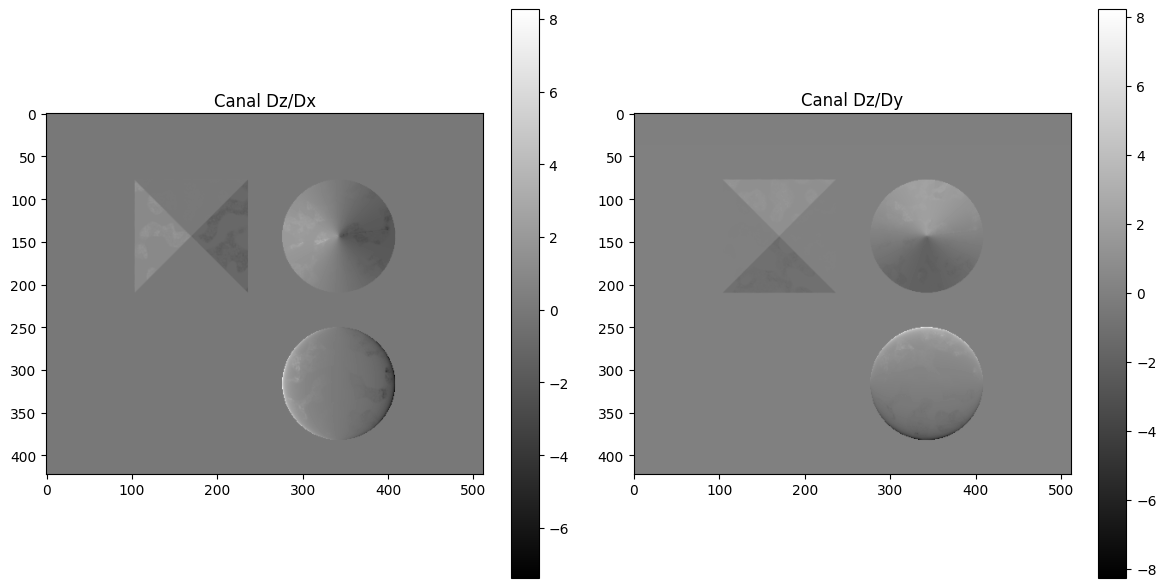

In [23]:
# Exemplo de uso

#normal_map_clean = np.clip(normal_map, np.percentile(normal_map, 2), np.percentile(normal_map, 80))

gradient_map = normal_map_to_gradient_map(normal_map)
print("Mapa de gradientes calculado com sucesso.")


#gradient_map = np.clip(gradient_map, np.percentile(gradient_map, 1), np.percentile(gradient_map, 95)) 

gradient_map[:,:,0] = -gradient_map[:,:,0] # Inverter o sinal do gradiente em y

# Plot the two images side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for idx, channel in enumerate(['Dz/Dx', 'Dz/Dy']):
    axes[idx].imshow(gradient_map[:, :, idx], cmap='gray')
    axes[idx].set_title(f"Canal {channel}")
    #axes[idx].axis('off')
    axes[idx].colorbar = plt.colorbar(axes[idx].imshow(gradient_map[:, :, idx], cmap='gray'), ax=axes[idx])



plt.tight_layout()
plt.show()

In [24]:
from common.io import convert_image_array_to_fni

confidence_extra_exp = np.expand_dims(normal_map[:,:,3], axis=-1)
gradient_map_with_confidence = np.concatenate((gradient_map, confidence_extra_exp), axis=-1)

convert_image_array_to_fni(gradient_map_with_confidence, 'gradiente_recursive.fni')

Mapa de gradientes calculado com sucesso.


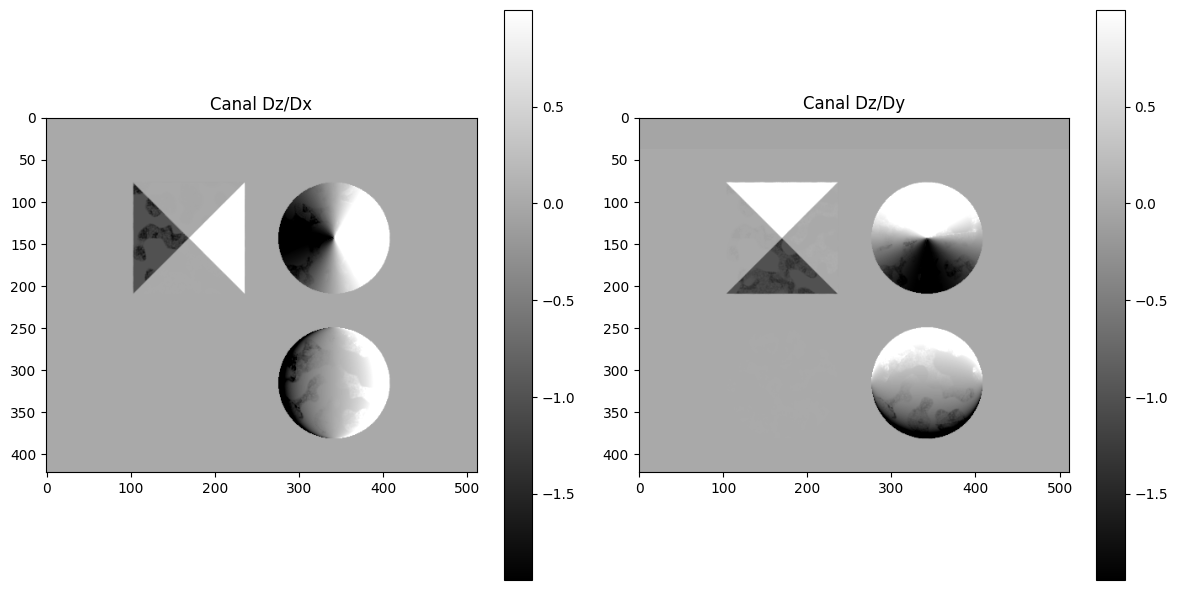

In [7]:
# Exemplo de uso
gradient_map = normal_map_to_gradient_map(normal_map)
print("Mapa de gradientes calculado com sucesso.")


gradient_map = np.clip(gradient_map, np.percentile(gradient_map, 1), np.percentile(gradient_map, 95)) 

# Plot the two images side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for idx, channel in enumerate(['Dz/Dx', 'Dz/Dy']):
    axes[idx].imshow(gradient_map[:, :, idx], cmap='gray')
    axes[idx].set_title(f"Canal {channel}")
    #axes[idx].axis('off')
    axes[idx].colorbar = plt.colorbar(axes[idx].imshow(gradient_map[:, :, idx], cmap='gray'), ax=axes[idx])



plt.tight_layout()
plt.show()

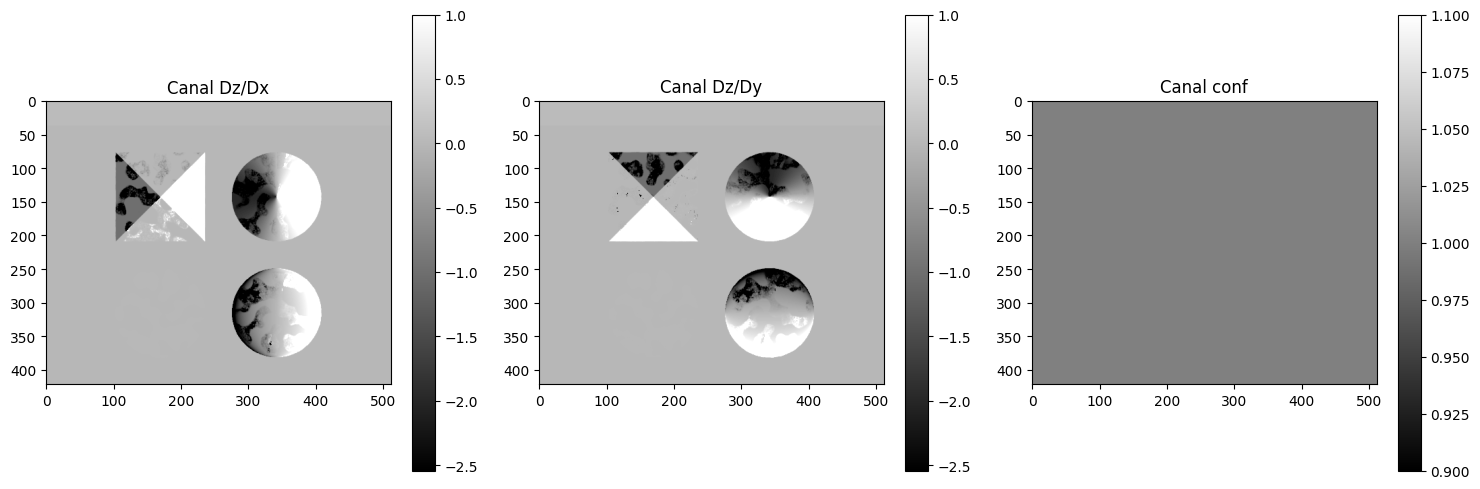

In [21]:
image = read_fni_to_image_array(f'/home/lelis/Documents/Projetos/hybrid-stereo-method/src/hybrid_method/integrate_recursive/teste-00-beg-G.fni')
#display_image(image=image, inline=True, colorbar=True)
# Exibir a imagem

image[:,:,0] = -image[:,:,0]
#image[:,:,1] = -image[:,:,1] 


image = np.clip(image, np.percentile(image, 1), np.percentile(image, 90)) 
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, channel in enumerate(['Dz/Dx', 'Dz/Dy', 'conf']):
    axes[idx].imshow(image[:, :, idx], cmap='gray')
    axes[idx].set_title(f"Canal {channel}")
    axes[idx].colorbar = plt.colorbar(axes[idx].imshow(image[:, :, idx], cmap='gray'), ax=axes[idx])
    #axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [33]:
from common.io import convert_image_array_to_fni

convert_image_array_to_fni(image, 'gradiente_recursive.fni')

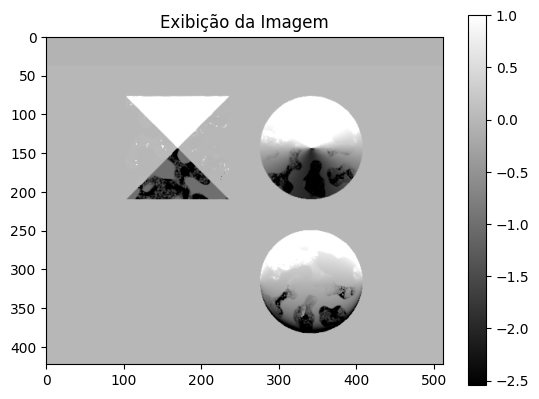

In [34]:
image = read_fni_to_image_array('gradiente_recursive.fni')
#display_image(image=image, inline=True, colorbar=True)
# Exibir a imagem
#image = np.clip(image, np.percentile(image, 5), np.percentile(image, 90))  # Clip values to be in the range [0, 1]
plt.imshow(image[:,:,1], cmap='gray')
plt.colorbar()
plt.title("Exibição da Imagem")
plt.show()

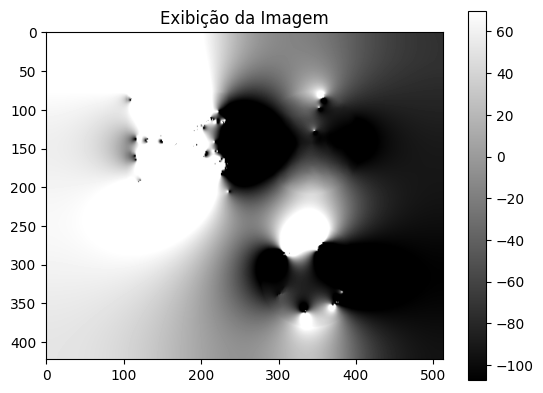

In [ ]:
image = read_fni_to_image_array(f'/home/lelis/Documents/Projetos/hybrid-stereo-method/src/hybrid_method/integrate_recursive/teste-00-end-Z.fni')
#display_image(image=image, inline=True, colorbar=True)
# Exibir a imagem
image = np.clip(image, np.percentile(image, 5), np.percentile(image, 90))  # Clip values to be in the range [0, 1]
plt.imshow(image[:,:,0], cmap='gray')
plt.colorbar()
plt.title("Exibição da Imagem")
plt.show()

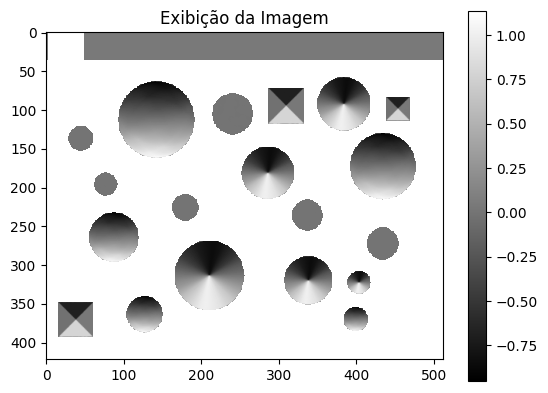

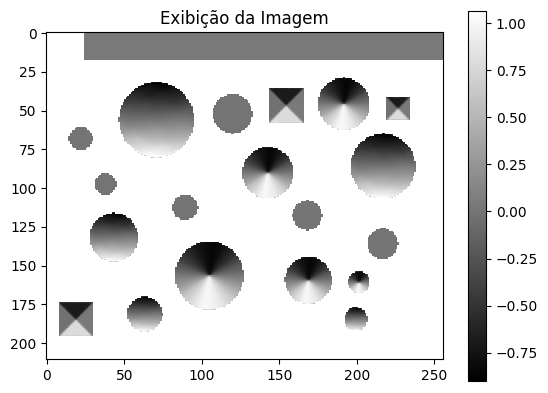

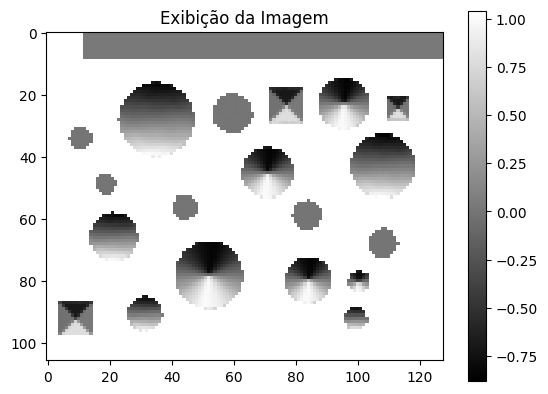

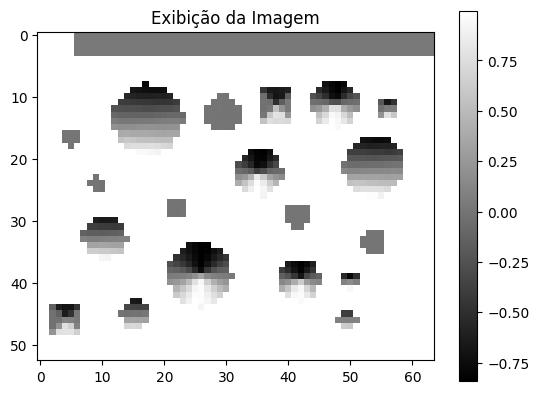

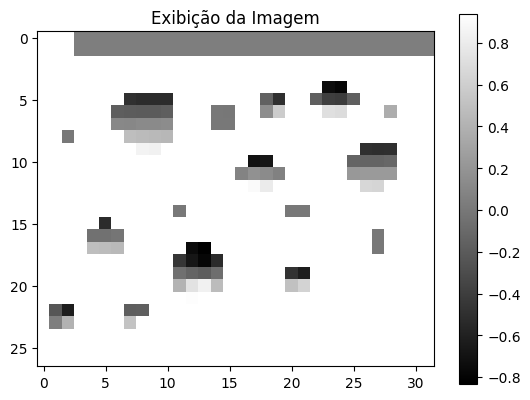

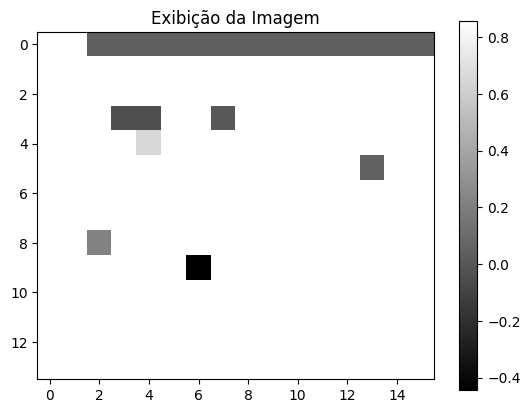

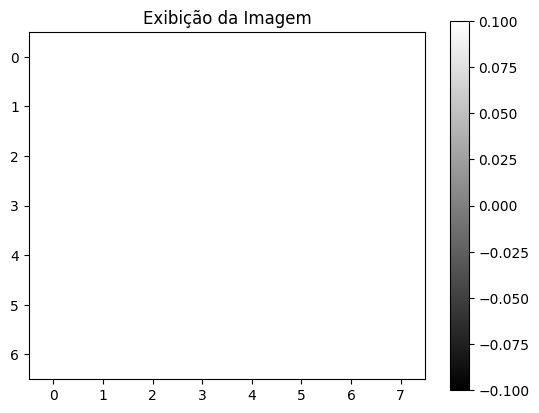

In [139]:
import numpy as np

for i in range (0,7):
    image = read_fni_to_image_array(f'/home/lelis/Documents/Projetos/hybrid-stereo-method/src/hybrid_method/integrate_recursive/teste/teste_2-0{i}-beg-G.fni')
    #display_image(image=image, inline=True, colorbar=True)
    # Exibir a imagem



    plt.imshow(image[:,:,1], cmap='gray')
    plt.colorbar()
    plt.title("Exibição da Imagem")
    plt.show()

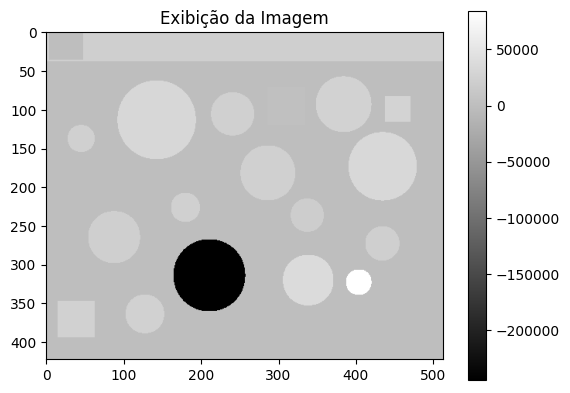

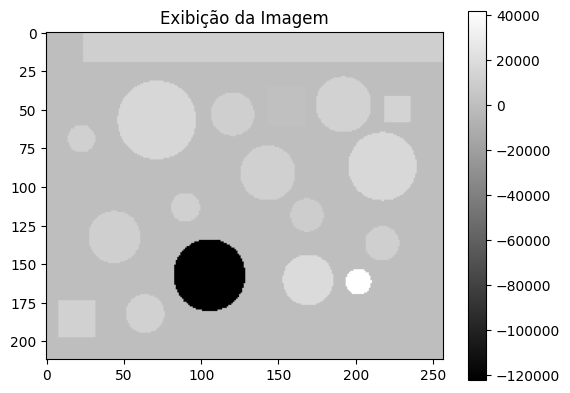

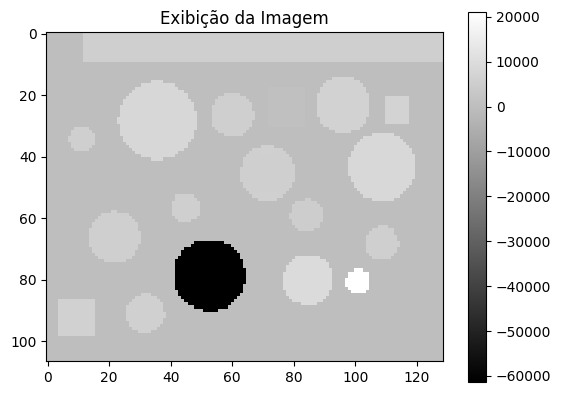

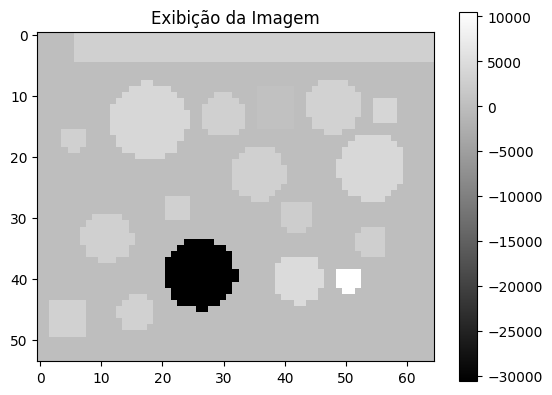

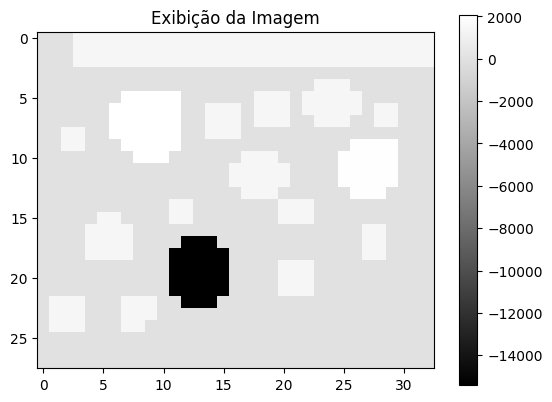

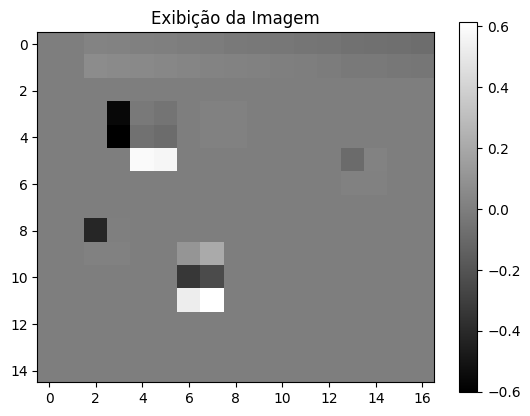

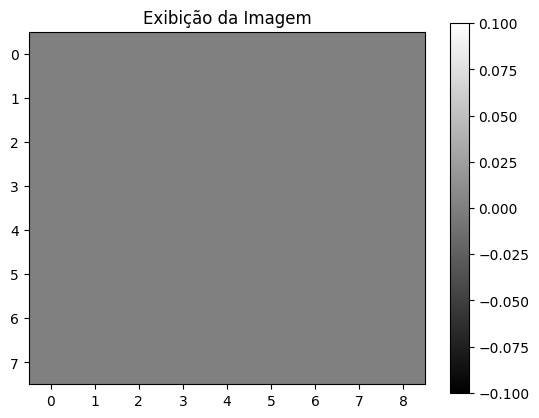

In [107]:
for i in range (0,7):
    image = read_fni_to_image_array(f'/home/lelis/Documents/Projetos/hybrid-stereo-method/src/hybrid_method/integrate_recursive/teste/teste_2-0{i}-end-Z.fni')
    #display_image(image=image, inline=True, colorbar=True)
    # Exibir a imagem
    plt.imshow(image[:,:,0], cmap='gray')
    plt.colorbar()
    plt.title("Exibição da Imagem")
    plt.show()

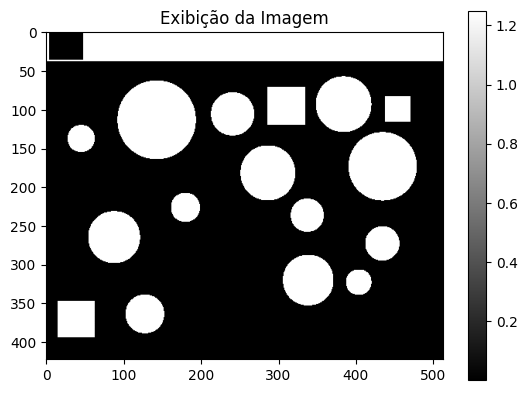

In [159]:
image = read_fni_to_image_array(f'/home/lelis/Documents/Projetos/hybrid-stereo-method/src/hybrid_method/integrate_recursive/teste/teste_2-00-end-Z.fni')
#display_image(image=image, inline=True, colorbar=True)
# Exibir a imagem
image = np.clip(image, np.percentile(image, 2), np.percentile(image, 80))  # Clip values to be in the range [0, 1]
#image = np.clip(image,0.0, 1.2)
plt.imshow(image[:,:,0], cmap='gray')
plt.colorbar()
plt.title("Exibição da Imagem")
plt.show()

In [119]:
np.percentile(image, 90)

np.float32(22503.469)

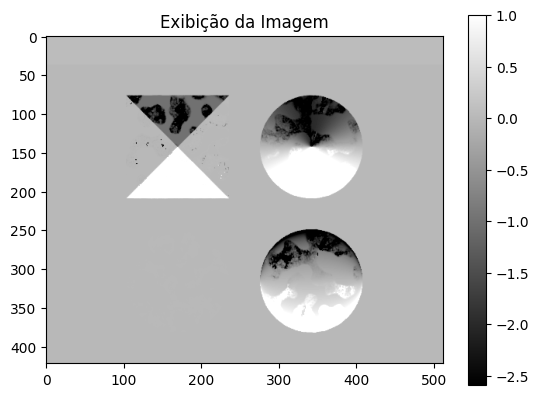

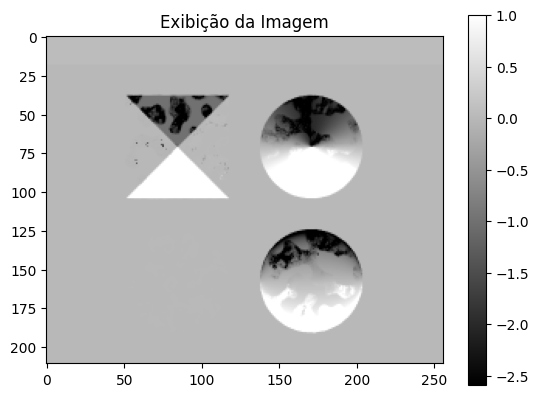

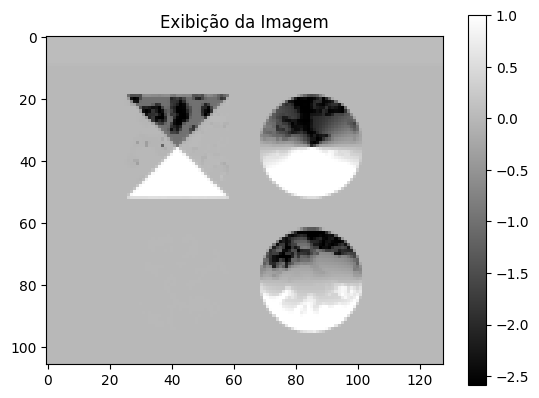

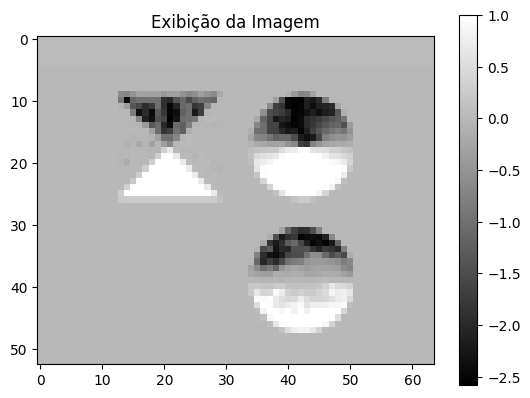

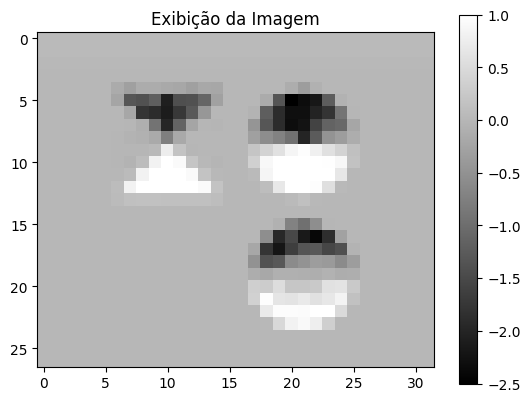

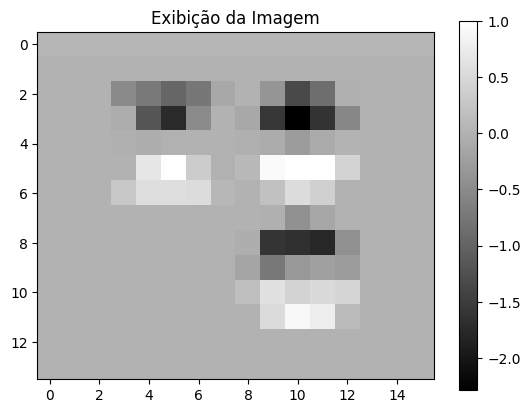

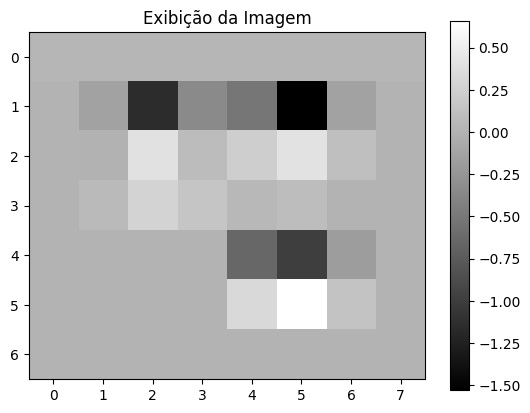

In [175]:
import numpy as np

for i in range (0,7):
    image = read_fni_to_image_array(f'/home/lelis/Documents/Projetos/hybrid-stereo-method/src/hybrid_method/integrate_recursive/teste_3/teste-0{i}-beg-G.fni')
    #display_image(image=image, inline=True, colorbar=True)
    # Exibir a imagem



    plt.imshow(image[:,:,1], cmap='gray')
    plt.colorbar()
    plt.title("Exibição da Imagem")
    plt.show()

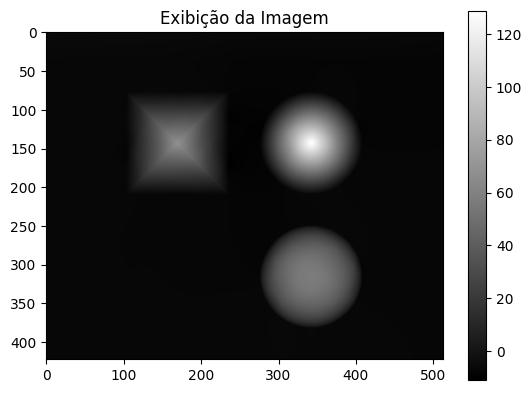

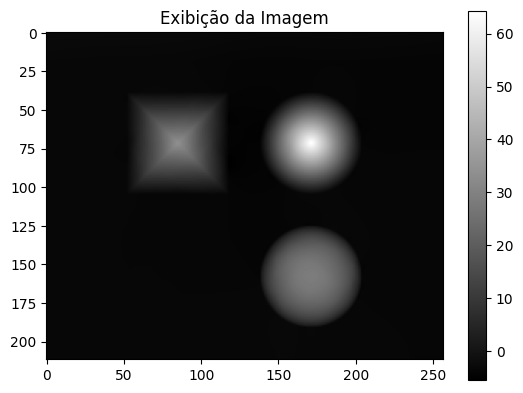

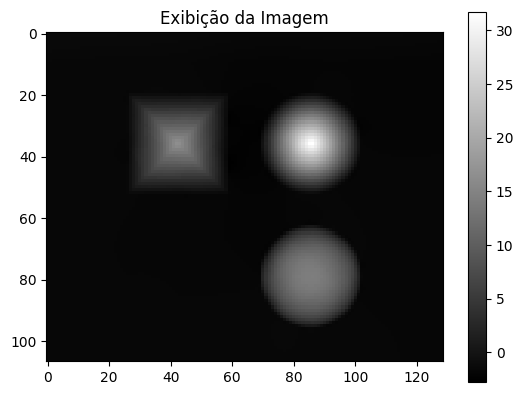

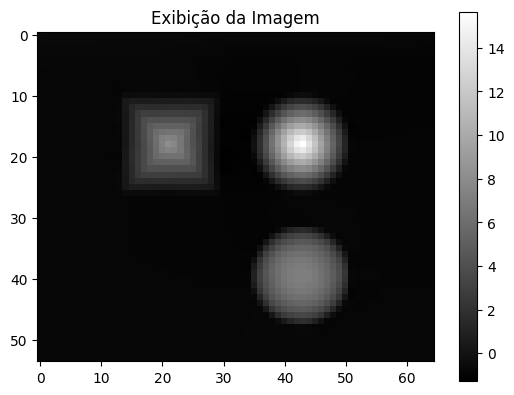

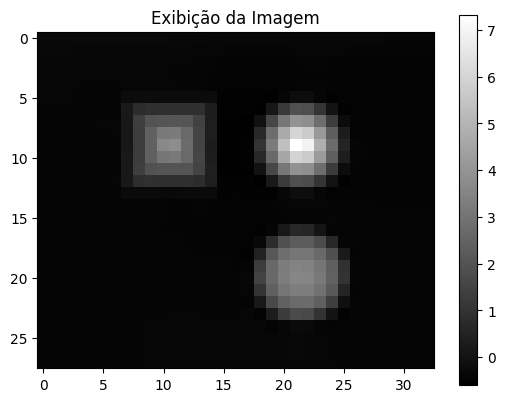

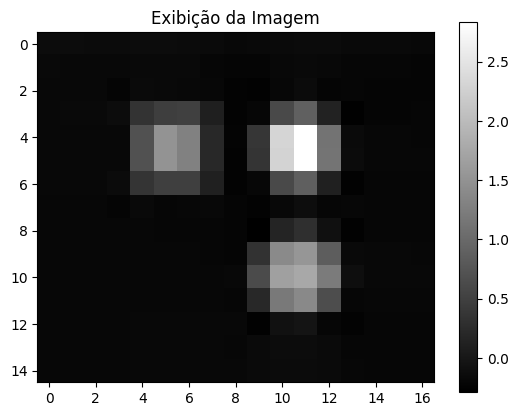

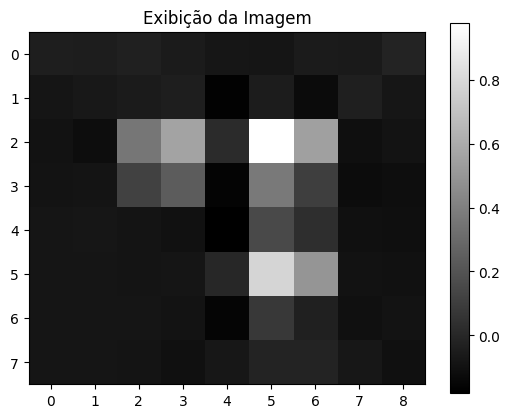

In [26]:
for i in range (0,7):
    image = read_fni_to_image_array(f'/home/lelis/Documents/Projetos/hybrid-stereo-method/src/hybrid_method/integrate_recursive/teste_7/teste-0{i}-end-Z.fni')
    #display_image(image=image, inline=True, colorbar=True)
    # Exibir a imagem
    plt.imshow(image[:,:,0], cmap='gray')
    plt.colorbar()
    plt.title("Exibição da Imagem")
    plt.show()

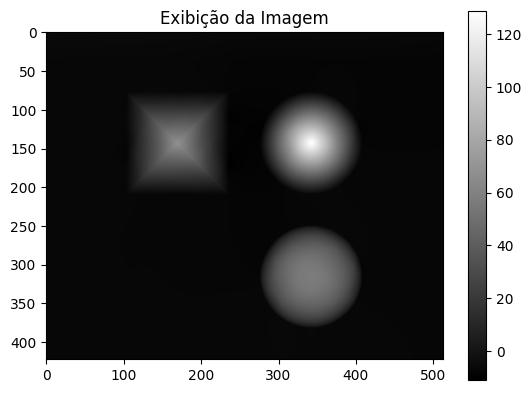

In [25]:
image = read_fni_to_image_array(f'/home/lelis/Documents/Projetos/hybrid-stereo-method/src/hybrid_method/integrate_recursive/teste_7/teste-00-end-Z.fni')
#display_image(image=image, inline=True, colorbar=True)
# Exibir a imagem
#image = np.clip(image, np.percentile(image, 2), np.percentile(image, 80))  # Clip values to be in the range [0, 1]
#image = np.clip(image,0.0, 1.2)
plt.imshow(image[:,:,0], cmap='gray')
plt.colorbar()
plt.title("Exibição da Imagem")
plt.show()

In [ ]:
np.percentile(image, 90)

np.float32(22503.469)